In [11]:
import pandas as pd

# --- Data File Path ---

data_file_path = '../1_data_collection/extracting_company_data/general_info.csv'

# --- Load Data ---

df_companies = pd.read_csv(data_file_path)
#print(f"Data successfully loaded from: {data_file_path}")

#df_companies.head(15)
df_companies.describe()
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   company        1040 non-null   object 
 1   website        1040 non-null   object 
 2   rating         1039 non-null   float64
 3   number_review  1039 non-null   float64
 4   domain         1040 non-null   object 
dtypes: float64(2), object(3)
memory usage: 40.8+ KB


Domain column already in list format or unexpected type. Skipping string evaluation.

--- All Domain Categories and their Frequencies ---
                        Domain Category  Number of Companies
                          Travel Agency                  721
                    Flights Search Site                  205
                          Tour Operator                  165
                      Travel Aggregator                  132
                        Vacation Rental                   94
                  Airline Ticket Agency                   91
                                  Hotel                   84
                      Travel & Vacation                   76
                                Airline                   58
                            Tour Agency                   42
                          Cruise Agency                   32
                Cultural Tours Provider                   31
                        Visa Consultant                   23
        

C:\Users\Dom\AppData\Local\Temp\ipykernel_12056\2080133640.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_40_categories.values, y=top_40_categories.index, palette='viridis')


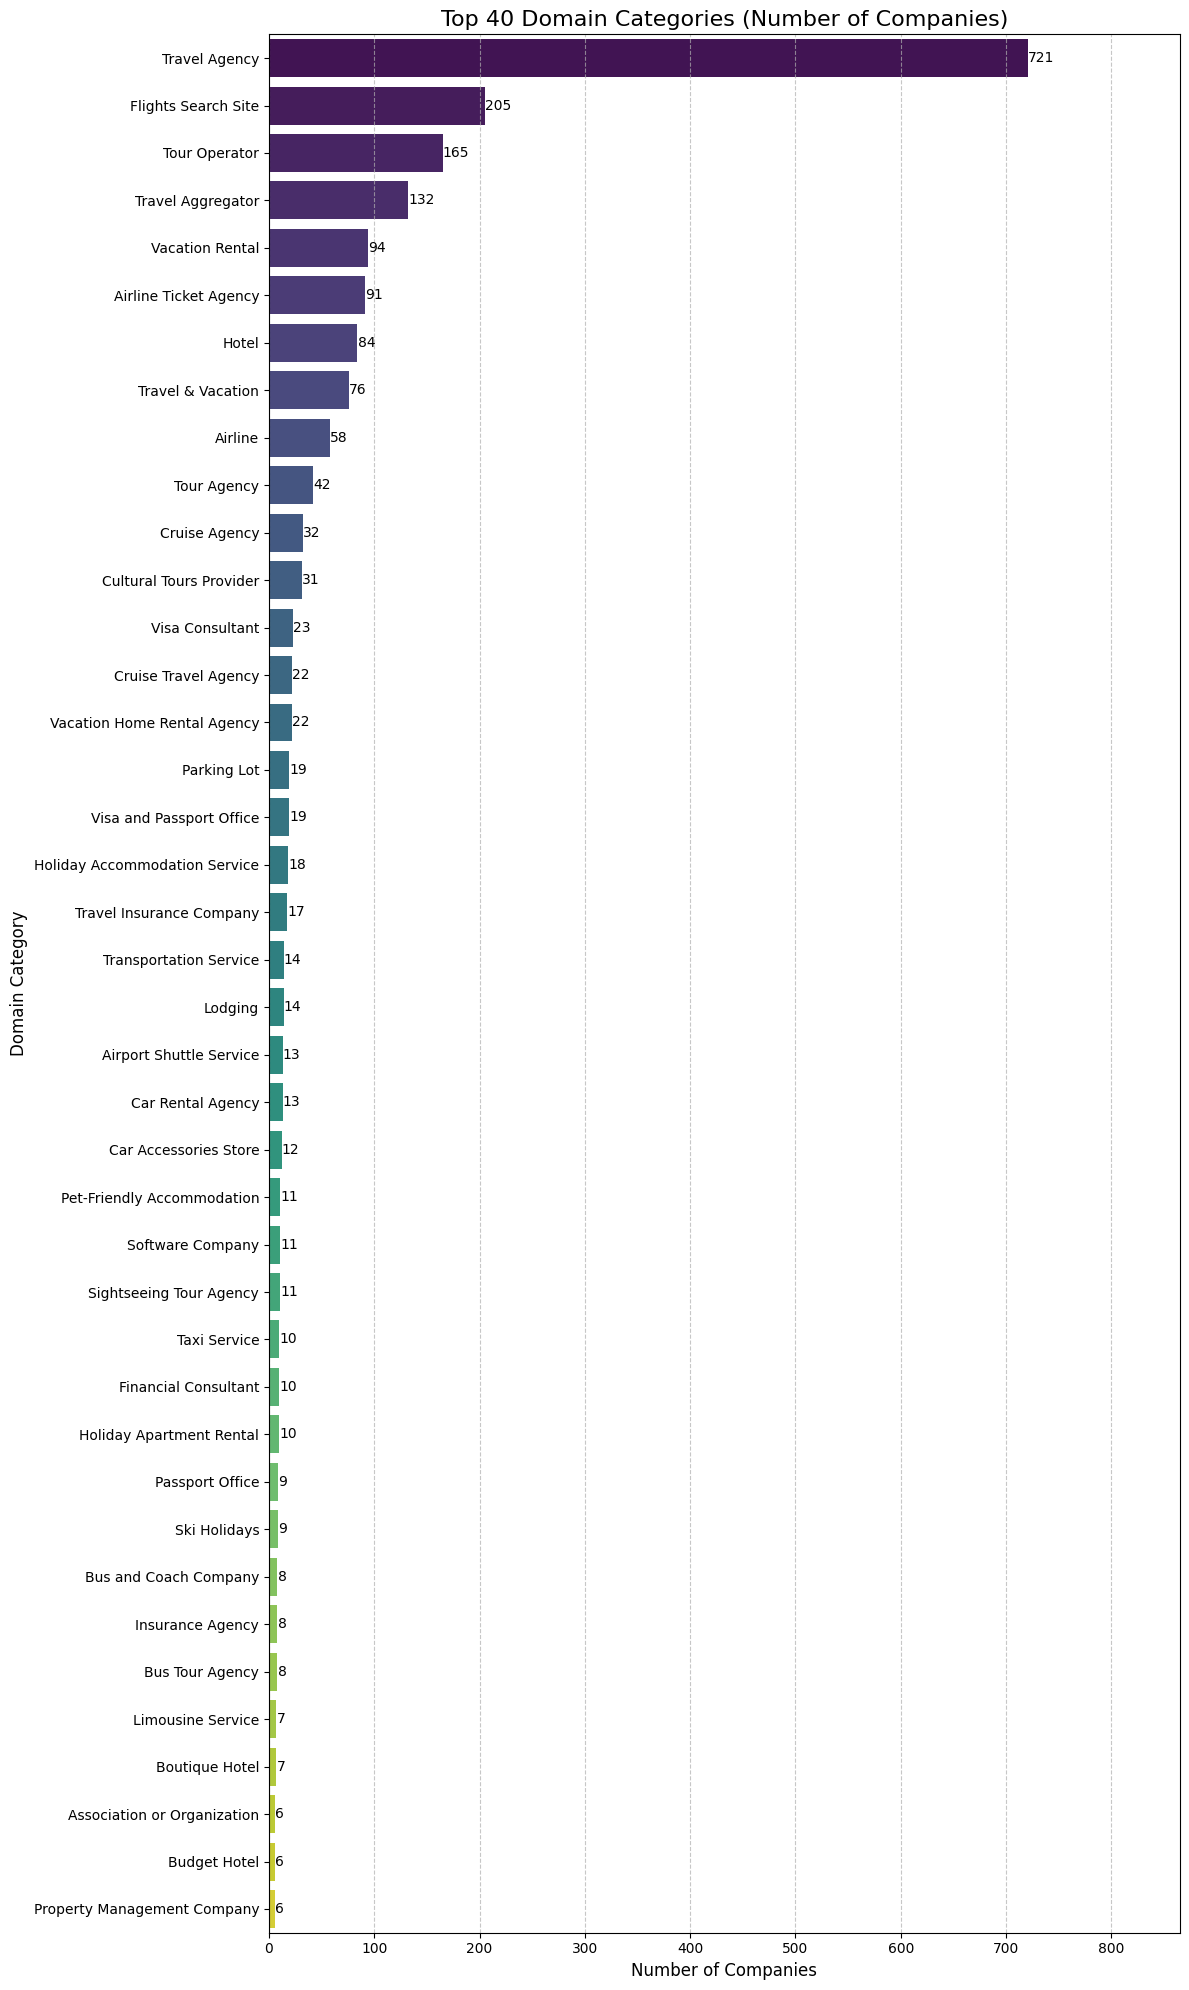

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import ast # For safely converting string representations of lists

# --- Data Cleaning and Preparation ---

# Ensure df_companies exists from the previous cell.
if 'df_companies' not in locals():
    print("Error: 'df_companies' DataFrame not found. Please run the data loading cell first.")
    sys.exit("Processing terminated: Data not loaded.")

# Convert 'domain' column strings to actual Python lists.
# Handles cases where data might already be in list format.
try:
    if isinstance(df_companies['domain'].iloc[0], str):
        df_companies['domain'] = df_companies['domain'].apply(lambda x: ast.literal_eval(x.strip()))
    else:
        print("Domain column already in list format or unexpected type. Skipping string evaluation.")
except Exception as e:
    print(f"Error parsing 'domain' column: {e}")
    sys.exit("Processing terminated due to domain column error.")

# Explode the 'domain' column to have one category per row.
df_exploded_categories = df_companies.explode('domain')

# Clean category names: remove trailing '...' and whitespace.
df_exploded_categories['domain'] = df_exploded_categories['domain'].str.replace(r'\.\.\.$', '', regex=True).str.strip()

# Calculate frequencies of all unique domain categories.
all_category_counts = df_exploded_categories['domain'].value_counts()

# --- Display All Categories (Table) ---

# Convert counts to a DataFrame for a clear table view.
df_all_categories_table = all_category_counts.reset_index()
df_all_categories_table.columns = ['Domain Category', 'Number of Companies']

print("\n" + "="*50)
print("--- All Domain Categories and their Frequencies ---")
print("="*50)
print(df_all_categories_table.to_string(index=False)) # Print without pandas index
print("="*50 + "\n")

# --- Visualize Top 40 Categories ---

# Select the top 40 most frequent categories for the plot.
top_40_categories = all_category_counts.head(40)

# Adjust plot height dynamically for better readability.
plot_height = max(10, len(top_40_categories) * 0.5)
plt.figure(figsize=(12, plot_height))

# Create a horizontal bar chart.
ax = sns.barplot(x=top_40_categories.values, y=top_40_categories.index, palette='viridis')

# Add count labels on each bar.
for index, value in enumerate(top_40_categories.values):
    ax.text(value + 0.2, index, str(value), va='center', ha='left', fontsize=10, color='black')

# Set plot title and labels.
plt.title('Top 40 Domain Categories (Number of Companies)', fontsize=16)
plt.xlabel('Number of Companies', fontsize=12)
plt.ylabel('Domain Category', fontsize=12)

# Adjust X-axis limit to ensure labels fit.
plt.xlim(right=top_40_categories.values.max() * 1.2)

# Add grid lines for readability.
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Optimize plot layout.
plt.tight_layout()

# Display the plot.
plt.show()